In [150]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,TargetEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error
from datetime import datetime
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv(r"C:\Programming\Machine Learning\Used Car Price Intelligence\Used Car Arbitrage\data\raw\raw_car_listings.csv")
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual


In [3]:
df.shape

(4258, 5)

In [4]:
def clean_price(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().replace("₹",'').replace(',','').strip()
    if 'crore' in val or 'cr' in val:
        num = re.findall(r'[\d\.]+',val)
        return float(num[0])*10000000 if num else np.nan
    elif 'lakh' in val or 'lac' in val:
            num = re.findall(r'[\d\.]+',val)
            return float(num[0])*100000 if num else np.nan
    else:
        num = re.findall(r'[\d\.]+',val)
        if num:
            n = float(num[0])
            return n
        return np.nan

In [5]:
def clean_kilometers(val):
    if pd.isna(val):
        return np.nan

    clean_val = str(val).lower().replace('km','').replace(',','').strip()
    try:
        return float(clean_val)
    except ValueError:
        return np.nan

In [6]:
df['clean_price'] = df['Price'].apply(clean_price)

In [7]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0


In [8]:
df['clean_kms'] = df['Kilometers'].apply(clean_kilometers)

In [9]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0


In [10]:
df['Transmission'].value_counts()['Missing Transmission']

np.int64(907)

In [11]:
df['updated_transmission'] = df['Transmission'].replace("Missing Transmission",np.nan)

In [12]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual


In [13]:
df['updated_transmission'].value_counts()

updated_transmission
Manual    3351
Name: count, dtype: int64

In [14]:
df['updated_transmission'].nunique(dropna=False)

2

sirf Nan or manual transmission present hai data mai 3351(manual)+907(Nan) = 4258. Automatic hai hi nahi

In [15]:
df['Year'] = df['Title'].str.extract(r'^(\d{4})')

In [16]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020


In [17]:
df['Brand'] = df['Title'].str.extract(r'^\d{4}\s+(\w+)')

In [18]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year,Brand
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015,Hyundai
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017,Maruti
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018,Datsun
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020,Tata
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020,Renault


In [19]:
df['Model'] = df['Title'].str.extract(r'^\d{4}\s+\w+\s+(.+)')

In [20]:
df.head()

,Title,Price,Kilometers,Fuel_Type,Transmission,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,2015 Hyundai Eon,₹1.72 lakh,"43,518 km",Petrol,Manual,172000.0,43518.0,Manual,2015,Hyundai,Eon
1,2017 Maruti Wagon R 1.0,₹2.39 lakh,"42,678 km",Petrol,Manual,239000.0,42678.0,Manual,2017,Maruti,Wagon R 1.0
2,2018 Datsun Redi Go,₹1.64 lakh,"60,214 km",CNG,Manual,164000.0,60214.0,Manual,2018,Datsun,Redi Go
3,2020 Tata NEXON,₹5.20 lakh,"50,912 km",Petrol,Manual,520000.0,50912.0,Manual,2020,Tata,NEXON
4,2020 Renault Kwid,₹2.50 lakh,"68,431 km",Petrol,Manual,250000.0,68431.0,Manual,2020,Renault,Kwid


In [21]:
df = df.drop(['Title','Price','Kilometers','Transmission'],axis = 1)

In [22]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,Petrol,172000.0,43518.0,Manual,2015,Hyundai,Eon
1,Petrol,239000.0,42678.0,Manual,2017,Maruti,Wagon R 1.0
2,CNG,164000.0,60214.0,Manual,2018,Datsun,Redi Go
3,Petrol,520000.0,50912.0,Manual,2020,Tata,NEXON
4,Petrol,250000.0,68431.0,Manual,2020,Renault,Kwid


In [23]:
df['clean_price'].describe()

count    4.258000e+03
mean     4.966101e+05
std      3.799964e+05
min      4.800000e+04
25%      2.322500e+05
50%      4.000000e+05
75%      6.500000e+05
max      5.005000e+06
Name: clean_price, dtype: float64

In [24]:
df['Brand'] = df['Brand'].str.lower()
df['Model'] = df['Model'].str.lower()

In [25]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
0,Petrol,172000.0,43518.0,Manual,2015,hyundai,eon
1,Petrol,239000.0,42678.0,Manual,2017,maruti,wagon r 1.0
2,CNG,164000.0,60214.0,Manual,2018,datsun,redi go
3,Petrol,520000.0,50912.0,Manual,2020,tata,nexon
4,Petrol,250000.0,68431.0,Manual,2020,renault,kwid


In [26]:
df['Fuel_Type'].value_counts(dropna=False)

Fuel_Type
Petrol      2891
CNG          884
Diesel       458
Hybrid        14
Electric      11
Name: count, dtype: int64

In [27]:
(df.isna().mean()*100).round(2)

Fuel_Type                0.0
clean_price              0.0
clean_kms                0.0
updated_transmission    21.3
Year                     0.0
Brand                    0.0
Model                    0.0
dtype: float64

In [28]:
df['Brand'].nunique()

24

<Axes: xlabel='clean_price', ylabel='Count'>

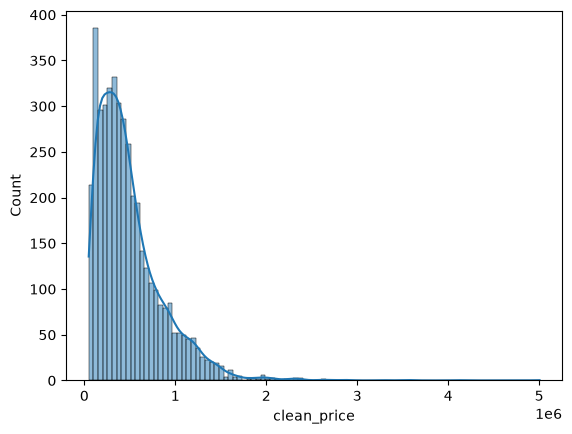

In [29]:
sns.histplot(data =df,x='clean_price',kde=True)

In [30]:
df['clean_price'].skew()

np.float64(2.300287519586333)

<Axes: xlabel='Fuel_Type', ylabel='clean_price'>

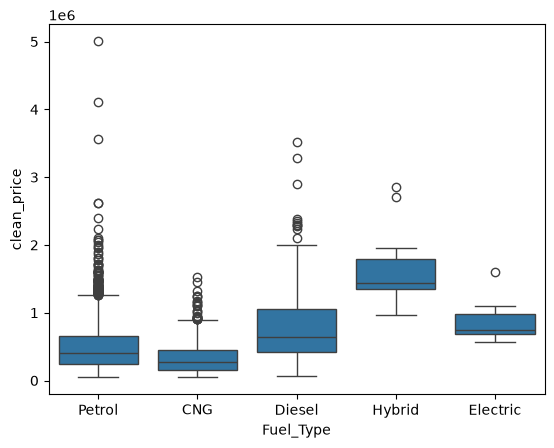

In [31]:
sns.boxplot(data = df, x='Fuel_Type',y='clean_price')

<Axes: xlabel='clean_kms', ylabel='clean_price'>

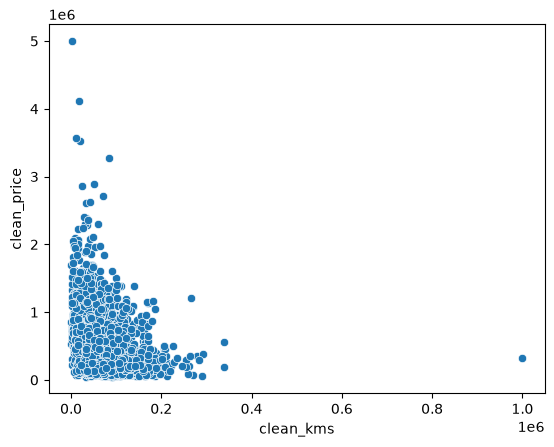

In [32]:
sns.scatterplot(data=df,x='clean_kms',y='clean_price')

In [33]:
df[df['clean_kms']>300000]

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
552,CNG,189000.0,338648.0,Manual,2016,maruti,wagon r 1.0
2283,Petrol,330000.0,999245.0,NaN,2017,maruti,baleno
4106,Diesel,567000.0,339522.0,Manual,2019,hyundai,venue


In [34]:
np.log1p(df['clean_price']).skew()

np.float64(-0.21100238410791378)

<Axes: xlabel='clean_price', ylabel='Count'>

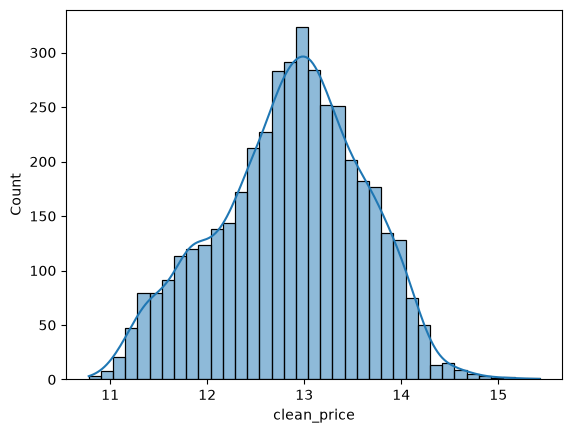

In [35]:
sns.histplot(data=df,x=np.log1p(df['clean_price']),kde=True)

In [36]:
df.query("clean_kms > 300000")

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model
552,CNG,189000.0,338648.0,Manual,2016,maruti,wagon r 1.0
2283,Petrol,330000.0,999245.0,NaN,2017,maruti,baleno
4106,Diesel,567000.0,339522.0,Manual,2019,hyundai,venue


In [37]:
df = df.drop(index=[552,2283,4106])

In [38]:
df.query("clean_kms>300000")

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model


In [39]:
current_year = datetime.now().year
df['car_age'] = current_year - df['Year'].astype(int)
df['km_per_year'] = df['clean_kms'] / np.maximum(1,df['car_age'])
df['brand_model'] = df['Brand'] + '_' + df['Model']

In [40]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,Year,Brand,Model,car_age,km_per_year,brand_model
0,Petrol,172000.0,43518.0,Manual,2015,hyundai,eon,11,3956.181818,hyundai_eon
1,Petrol,239000.0,42678.0,Manual,2017,maruti,wagon r 1.0,9,4742.000000,maruti_wagon r 1.0
2,CNG,164000.0,60214.0,Manual,2018,datsun,redi go,8,7526.750000,datsun_redi go
3,Petrol,520000.0,50912.0,Manual,2020,tata,nexon,6,8485.333333,tata_nexon
4,Petrol,250000.0,68431.0,Manual,2020,renault,kwid,6,11405.166667,renault_kwid


In [41]:
df = df.drop(['Year','Brand','Model'],axis = 1)

In [42]:
df.head()

,Fuel_Type,clean_price,clean_kms,updated_transmission,car_age,km_per_year,brand_model
0,Petrol,172000.0,43518.0,Manual,11,3956.181818,hyundai_eon
1,Petrol,239000.0,42678.0,Manual,9,4742.000000,maruti_wagon r 1.0
2,CNG,164000.0,60214.0,Manual,8,7526.750000,datsun_redi go
3,Petrol,520000.0,50912.0,Manual,6,8485.333333,tata_nexon
4,Petrol,250000.0,68431.0,Manual,6,11405.166667,renault_kwid


In [43]:
df.to_csv(r"C:\Programming\Machine Learning\Used Car Price Intelligence\Used Car Arbitrage\data\Processed\clean_car_listing.csv",index=False)

In [44]:
X = df[["brand_model","Fuel_Type","km_per_year","car_age","clean_kms"]]
y = np.log1p(df['clean_price'])

In [45]:
X.shape

(4255, 5)

In [46]:
y.shape

(4255,)

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
X_train.shape

(3404, 5)

In [49]:
y_train.shape

(3404,)

In [50]:
num_cols = ['clean_kms','car_age','km_per_year']
ohe_cols = ['Fuel_Type']
target_cols = ['brand_model']

In [51]:
preprocessor = ColumnTransformer(transformers=[
    ('num',StandardScaler(),num_cols),
    ('ohe',OneHotEncoder(),ohe_cols),
    ('target',TargetEncoder(),target_cols)
])

In [52]:
lr_pipe =Pipeline([('prep',preprocessor),('model',LinearRegression())])

In [53]:
lr_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['brand_model','Fuel_Type','km_per_year','car_age','clean_kms']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

In [54]:
y_train_pred=lr_pipe.predict(X_train)

In [55]:
y_train_pred

array([11.58401031, 11.70453227, 13.47796785, ..., 11.45832091,
       13.43560866, 12.92289219], shape=(3404,))

In [56]:
y_test_pred = lr_pipe.predict(X_test)

In [57]:
y_test_pred

array([12.18471483, 11.55461275, 14.65261254, 13.07192058, 11.74261678,
       12.70400256, 11.56111227, 11.57507297, 13.23049976, 11.91169314,
       13.38699908, 11.46815238, 12.71244249, 12.52414729, 13.49705177,
       12.56225504, 12.2166552 , 12.73296676, 12.70016096, 13.3522331 ,
       12.89427733, 11.70524643, 12.49845006, 12.51086298, 11.5492878 ,
       12.79477875, 12.51625965, 12.93871396, 13.0842332 , 12.56457026,
       12.0157839 , 12.41270213, 13.3745492 , 13.60577916, 12.1491499 ,
       12.11320727, 11.90351962, 12.99808585, 11.99525006, 12.35421185,
       12.78646858, 12.63145373, 13.17777627, 12.52176608, 12.46800583,
       13.60231726, 11.97658073, 12.70027046, 11.89238118, 12.7678047 ,
       13.11353503, 12.05834192, 13.98284574, 13.86083549, 11.41130678,
       12.70669662, 13.07705886, 11.9669368 , 12.67564974, 12.04397976,
       12.58979996, 11.94775274, 13.15074905, 12.74003514, 11.64380634,
       11.55661304, 12.76191524, 12.93731852, 13.90216743, 11.82

In [58]:
y_test_pred.shape

(851,)

In [59]:
n = X.shape[0]
p = X.shape[1]
print("N: ",n,' P: ',p)

N:  4255  P:  5


In [60]:
r2_train = r2_score(y_train,y_train_pred)

In [61]:
r2_train

0.8904638263546594

In [62]:
adj_r2_train = 1-((1-r2_train)*(n-1)/(n-p-1))

In [63]:
adj_r2_train

0.8903349299394495

In [64]:
r2_test = r2_score(y_test,y_test_pred)

In [65]:
r2_test

0.8629632834278443

In [66]:
adj_r2_test = 1-((1-r2_test)*(n-1)/(n-p-1))

In [67]:
adj_r2_test

0.8628020258183219

In [68]:
rmse_train = root_mean_squared_error(y_train,y_train_pred)

In [69]:
rmse_train

0.25022633564456226

In [70]:
rmse_test = root_mean_squared_error(y_test,y_test_pred)

In [71]:
rmse_test

0.2726013487090304

In [72]:
mae_train = mean_absolute_error(y_train,y_train_pred)

In [73]:
mae_train

0.19461972371398062

In [74]:
mae_test = mean_absolute_error(y_test,y_test_pred)

In [75]:
mae_test

0.20151018756815836

r2 score (train, test) = 0.89, 0.86 || adj_r2 (train,test) = 0.89, 0.86 ||
RMSE = 0.25, 0.27 ||
MAE = 0.19, 0.20 |

In [76]:
ridge_pipe = Pipeline([('prep',preprocessor),('model',Ridge())])

In [77]:
ridge_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [78]:
param_grid = {'model__alpha':[0.01,0.1,1.0,5.0,10.0,20.0,50.0,100.0]}

In [79]:
grid_ridge = GridSearchCV(ridge_pipe,param_grid,cv = 5, scoring='r2')

In [80]:
grid_ridge

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [81]:
grid_ridge.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [82]:
grid_ridge.best_params_

{'model__alpha': 0.1}

In [83]:
grid_ridge.best_score_

np.float64(0.8675381349992483)

In [84]:
y_train_pred_ridge = grid_ridge.predict(X_train)

In [85]:
y_test_pred_ridge = grid_ridge.predict(X_test)

In [86]:
r2_train_ridge = r2_score(y_train,y_train_pred_ridge)

In [87]:
r2_train_ridge

0.8903881520969985

In [88]:
r2_test_ridge = r2_score(y_test,y_test_pred_ridge)

In [89]:
r2_test_ridge

0.8627782759844661

In [90]:
adj_r2_train_ridge = 1-((1-r2_train_ridge)*(n-1)/(n-p-1))

In [91]:
adj_r2_train_ridge

0.8902591666322974

In [92]:
adj_r2_test_ridge = 1-((1-r2_test_ridge)*(n-1)/(n-p-1))

In [93]:
adj_r2_test_ridge

0.8626168006679027

In [94]:
rmse_train_ridge = root_mean_squared_error(y_train,y_train_pred_ridge)

In [95]:
rmse_train_ridge

0.2503127565145545

In [96]:
rmse_test_ridge = root_mean_squared_error(y_test,y_test_pred_ridge)

In [97]:
rmse_test_ridge

0.272785300387718

In [98]:
mae_train_ridge = mean_absolute_error(y_train,y_train_pred_ridge)

In [99]:
mae_train_ridge

0.19477896815960738

In [100]:
mae_test_ridge = mean_absolute_error(y_test, y_test_pred_ridge)

In [101]:
mae_test_ridge

0.20159036310698028

r2 score (train, test) = 0.89, 0.86 || adj_r2 (train,test) = 0.89, 0.86 ||
RMSE = 0.25, 0.27 ||
MAE = 0.19, 0.20 |

In [102]:
lasso_pipe = Pipeline([('prep',preprocessor),('model',Lasso(random_state=42,max_iter=1000))])

In [103]:
lasso_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [104]:
param_grid_Lasso = {'model__alpha':[0.0001,0.0005,0.001,0.005,0.01,0.05,0.1,1.0,5.0,10.0]}

In [105]:
grid_lasso = GridSearchCV(lasso_pipe,param_grid_Lasso,cv = 5, scoring='r2')

In [106]:
grid_lasso

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [107]:
grid_lasso = grid_lasso.fit(X_train,y_train)

In [108]:
grid_lasso

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [109]:
grid_lasso.best_params_

{'model__alpha': 0.0001}

In [110]:
grid_lasso.best_score_

np.float64(0.8674597324116349)

In [111]:
y_train_pred_lasso = grid_lasso.predict(X_train)

In [112]:
y_train_pred_lasso

array([11.57993731, 11.70004855, 13.48367434, ..., 11.45483855,
       13.43581557, 12.91967394], shape=(3404,))

In [113]:
y_test_pred_lasso = grid_lasso.predict(X_test)

In [114]:
y_test_pred_lasso

array([12.18448546, 11.55186921, 14.6553051 , 13.07178329, 11.74114305,
       12.70218735, 11.55845049, 11.57084357, 13.23368534, 11.90978291,
       13.38345858, 11.46484207, 12.70903829, 12.51956515, 13.4991994 ,
       12.55853181, 12.21622846, 12.72706588, 12.69564807, 13.35344623,
       12.89384556, 11.70168867, 12.49156797, 12.50616648, 11.54647727,
       12.7973216 , 12.51416328, 12.93748056, 13.08508588, 12.56397921,
       12.01143993, 12.40890551, 13.37210442, 13.60170737, 12.14968406,
       12.11205439, 11.89905893, 13.00373792, 11.9940369 , 12.35042402,
       12.78521044, 12.62733435, 13.18134282, 12.51698529, 12.46533697,
       13.60299994, 11.97389556, 12.6962764 , 11.89040911, 12.76560943,
       13.11285685, 12.05801622, 13.98073187, 13.86066817, 11.40930935,
       12.70082914, 13.07600155, 11.96422074, 12.672697  , 12.04195714,
       12.58591981, 11.94632029, 13.15278629, 12.73725099, 11.64152621,
       11.55127523, 12.76153861, 12.93407667, 13.90239019, 11.82

In [115]:
r2_train_lasso = r2_score(y_train,y_train_pred_lasso)

In [116]:
r2_train_lasso

0.8901347959110952

In [117]:
r2_test_lasso = r2_score(y_test,y_test_pred_lasso)

In [118]:
r2_test_lasso

0.8630906011815295

In [119]:
adj_r2_train_lasso = 1-((1-r2_train_lasso)*(n-1)/(n-p-1))

In [120]:
adj_r2_train_lasso

0.8900055123101434

In [121]:
adj_r2_test_lasso = 1-((1-r2_test_lasso)*(n-1)/(n-p-1))

In [122]:
adj_r2_test_lasso

0.8629294933928515

In [123]:
rmse_train_lasso = root_mean_squared_error(y_train,y_train_pred_lasso)

In [124]:
rmse_train_lasso

0.25060187526682953

In [125]:
rmse_test_lasso = root_mean_squared_error(y_test,y_test_pred_lasso)

In [126]:
rmse_test_lasso

0.27247468536887887

In [127]:
mae_train_lasso = mean_absolute_error(y_train,y_train_pred_lasso)

In [128]:
mae_train_lasso

0.19499765806798253

In [129]:
mae_test_lasso = mean_absolute_error(y_test,y_test_pred_lasso)

In [130]:
mae_test_lasso

0.2014944187667269

r2 score (train, test) = 0.89, 0.86 || adj_r2 (train,test) = 0.89, 0.86 ||
RMSE = 0.25, 0.27 ||
MAE = 0.19, 0.20 |

In [131]:
elastic_pipe = Pipeline([("prep",preprocessor),("model",ElasticNet(random_state=42,max_iter=2000))])

In [132]:
elastic_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [133]:
parameter_grid_elastic = {
    'model__alpha':[0.0001,0.0005,0.001,0.01,0.1,1.0],
    'model__l1_ratio':[0.1,0.3,0.5,0.7,0.9]
}

In [134]:
grid_elastic = GridSearchCV(elastic_pipe,parameter_grid_elastic,cv = 5,scoring='r2')

In [135]:
grid_elastic

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...], 'model__l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [136]:
grid_elastic.fit(X_train,y_train)

c:\Users\Lenovo\anaconda3\envs\car_arbitrage\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.174746e-01, tolerance: 1.485e-01
  model = cd_fast.enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.0005, ...], 'model__l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

In [137]:
grid_elastic.best_score_

np.float64(0.867546902791392)

In [138]:
grid_elastic.best_params_

{'model__alpha': 0.0001, 'model__l1_ratio': 0.9}

In [139]:
y_train_pred_elastic = grid_elastic.predict(X_train)
y_test_pred_elastic = grid_elastic.predict(X_test)

In [140]:
y_test_pred_elastic

array([12.18702907, 11.55509438, 14.65663879, 13.0738018 , 11.74429554,
       12.70422484, 11.56169433, 11.57399553, 13.2342754 , 11.91332495,
       13.385697  , 11.46807843, 12.71183027, 12.52175673, 13.49863558,
       12.56055896, 12.21880761, 12.72961471, 12.69749226, 13.35335969,
       12.89517875, 11.70520847, 12.49447755, 12.50870001, 11.54968716,
       12.79893483, 12.51636152, 12.93971173, 13.0866341 , 12.56679767,
       12.01432677, 12.41155019, 13.37289389, 13.60277014, 12.15255857,
       12.11456553, 11.90209777, 13.00255965, 11.99746602, 12.35309729,
       12.78652215, 12.62927994, 13.18143634, 12.51945555, 12.46811739,
       13.60592006, 11.97701217, 12.69933384, 11.89379431, 12.76763678,
       13.11385314, 12.0610229 , 13.98276942, 13.86152332, 11.412619  ,
       12.70309881, 13.07744347, 11.96725903, 12.67456729, 12.04481996,
       12.58800926, 11.94935037, 13.15377968, 12.73947418, 11.64464002,
       11.55486912, 12.76279374, 12.93615977, 13.90112579, 11.82

In [141]:
y_test_pred_elastic

array([12.18702907, 11.55509438, 14.65663879, 13.0738018 , 11.74429554,
       12.70422484, 11.56169433, 11.57399553, 13.2342754 , 11.91332495,
       13.385697  , 11.46807843, 12.71183027, 12.52175673, 13.49863558,
       12.56055896, 12.21880761, 12.72961471, 12.69749226, 13.35335969,
       12.89517875, 11.70520847, 12.49447755, 12.50870001, 11.54968716,
       12.79893483, 12.51636152, 12.93971173, 13.0866341 , 12.56679767,
       12.01432677, 12.41155019, 13.37289389, 13.60277014, 12.15255857,
       12.11456553, 11.90209777, 13.00255965, 11.99746602, 12.35309729,
       12.78652215, 12.62927994, 13.18143634, 12.51945555, 12.46811739,
       13.60592006, 11.97701217, 12.69933384, 11.89379431, 12.76763678,
       13.11385314, 12.0610229 , 13.98276942, 13.86152332, 11.412619  ,
       12.70309881, 13.07744347, 11.96725903, 12.67456729, 12.04481996,
       12.58800926, 11.94935037, 13.15377968, 12.73947418, 11.64464002,
       11.55486912, 12.76279374, 12.93615977, 13.90112579, 11.82

In [142]:
r2_train_elastic = r2_score(y_train, y_train_pred_elastic)

In [143]:
r2_train_elastic

0.8902826271521724

In [144]:
r2_test_elastic = r2_score(y_test, y_test_pred_elastic)

In [145]:
r2_test_elastic

0.8631503189682372

In [146]:
rmse_test_elastic = root_mean_squared_error(y_test,y_test_pred_elastic)

In [147]:
rmse_test_elastic

0.27241525424133833

In [148]:
mae_test_elastic = mean_absolute_error(y_test, y_test_pred_elastic)

In [149]:
mae_test_elastic

0.20148467743785692

r2 (train, test) = 0.89, 8.86 || RMSE test = 0.27 || MAE test = 0.20